# IMPROVE FED RT Proxy Figure 2

This notebook tests what we can recover from the public/exported IMPROVE FED reflectance/transmittance fields:

- `RefI_635`, `TransI_635`
- `RefF_635`, `TransF_635`
- `RefM_635`, `TransM_635`

These are **not** Warren et al. Figure 2 raw registered HIPS detector outputs. The FED parameter table labels them as 635 nm reflectance/transmittance **ratios**. The goal here is narrower: make Figure-2-style proxy plots to see whether the available fields show useful structure for high-`fAbs` / ETAD-comparable samples.

The notebook also makes a SPARTAN analog with `HIPS_R1` and `HIPS_T1`, because SPARTAN has raw-looking R/T fields plus field blanks and lot IDs.

## Interpretation Rules

- Use these plots as **diagnostics**, not as a calibration reproduction.
- Do not fit a Warren-style blank OLS line to IMPROVE unless field blanks are actually present in the exported table.
- For IMPROVE, color or highlight by `fAbs`, ETAD-comparable rows, and high-tail rows.
- For SPARTAN, mark field blanks and samples because `FilterType` is available.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path('/Users/ahmadjalil/github/aethmodular')
SPARTAN_DIR = PROJECT_DIR / 'research' / 'ftir_hips_chem'
IMPROVE_CLEAN_PATH = SPARTAN_DIR / 'output' / 'improve_high_fabs_comparison' / 'improve_valid_cleaned.csv'
OUT_DIR = PROJECT_DIR / 'research' / 'improve_hips_offset' / 'output' / 'improve_fed_rt_proxy_figure2'
OUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SPARTAN_DIR / 'scripts'))
from config import MAC_VALUE
from outliers import apply_exclusion_flags, apply_threshold_flags
from plotting import apply_default_style

apply_default_style()
warnings.filterwarnings('ignore', category=FutureWarning)

STABLE_YEAR = 2003
SITE_CODE_TO_NAME = {'CHTS': 'Beijing', 'INDH': 'Delhi', 'USPA': 'JPL', 'ETAD': 'Addis_Ababa'}
SITE_ORDER = ['Beijing', 'Delhi', 'JPL', 'Addis_Ababa']
SPARTAN_FILTER_PATH = SPARTAN_DIR / 'Filter Data' / 'unified_filter_dataset.pkl'
print(f'Outputs: {OUT_DIR}')

Outputs: /Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_fed_rt_proxy_figure2


## Load IMPROVE FED RT Proxy Fields

In [2]:
usecols = [
    'Dataset', 'SiteCode', 'POC', 'Date', 'AuxID', 'ECf_Val', 'fAbs_Val',
    'EC_loading_ug', 'EC_loading_ug_cm2_primary', 'SiteName', 'State', 'Latitude', 'Longitude',
    'RefF_635_Val', 'TransF_635_Val', 'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val', 'rt_available',
]
improve = pd.read_csv(IMPROVE_CLEAN_PATH, usecols=lambda c: c in set(usecols), parse_dates=['Date'])
improve['year'] = improve['Date'].dt.year
improve['post_2003'] = improve['year'] >= STABLE_YEAR
improve['valid_loading'] = improve['EC_loading_ug'].notna() & improve['EC_loading_ug_cm2_primary'].notna()
improve['rt_available'] = improve['rt_available'].fillna(False).astype(bool)

rt_pairs = {
    'initial': ('RefI_635_Val', 'TransI_635_Val'),
    'final': ('RefF_635_Val', 'TransF_635_Val'),
    'minimum': ('RefM_635_Val', 'TransM_635_Val'),
}
for label, (rcol, tcol) in rt_pairs.items():
    improve[f'has_{label}_rt'] = improve[[rcol, tcol]].notna().all(axis=1)

availability = pd.DataFrame([
    {'group': 'all cleaned rows', 'n': len(improve)},
    {'group': 'post-2003', 'n': int(improve['post_2003'].sum())},
    {'group': 'post-2003 rt_available flag', 'n': int((improve['post_2003'] & improve['rt_available']).sum())},
    {'group': 'post-2003 initial RT pair', 'n': int((improve['post_2003'] & improve['has_initial_rt']).sum())},
    {'group': 'post-2003 final RT pair', 'n': int((improve['post_2003'] & improve['has_final_rt']).sum())},
    {'group': 'post-2003 minimum RT pair', 'n': int((improve['post_2003'] & improve['has_minimum_rt']).sum())},
])
availability.to_csv(OUT_DIR / 'improve_fed_rt_proxy_availability.csv', index=False)
display(availability)

year_avail = (
    improve.groupby('year')
    .agg(
        rows=('fAbs_Val', 'size'),
        initial_rt=('has_initial_rt', 'sum'),
        final_rt=('has_final_rt', 'sum'),
        minimum_rt=('has_minimum_rt', 'sum'),
    )
    .reset_index()
)
year_avail.to_csv(OUT_DIR / 'improve_fed_rt_proxy_year_availability.csv', index=False)
display(year_avail.tail(15))

,group,n
0,all cleaned rows,379697
1,post-2003,379697
2,post-2003 rt_available flag,147380
3,post-2003 initial RT pair,147380
4,post-2003 final RT pair,147380
5,post-2003 minimum RT pair,147380


,year,rows,initial_rt,final_rt,minimum_rt
8,2011,17823,0,0,0
9,2012,18052,0,0,0
10,2013,17358,0,0,0
11,2014,17053,0,0,0
12,2015,16877,0,0,0
13,2016,15736,15736,15736,15736
14,2017,16640,16640,16640,16640
15,2018,16505,16505,16505,16505
16,2019,16344,16344,16344,16344
17,2020,16730,16730,16730,16730


## Rebuild ETAD/Addis Bounds for Highlighting

The highlighted ETAD-comparable group uses Addis p05-p95 ranges for `fAbs`, EC mass, and EC surface loading.

In [3]:
def load_spartan_clean():
    df_long = pd.read_pickle(SPARTAN_FILTER_PATH)
    df_long['SampleDate'] = pd.to_datetime(df_long['SampleDate'], errors='coerce')
    df_long['SiteName'] = df_long['Site'].map(SITE_CODE_TO_NAME)
    params = ['EC_ftir', 'HIPS_Fabs', 'HIPS_R1', 'HIPS_T1', 'HIPS_r', 'HIPS_t', 'HIPS_tau']
    wide = (
        df_long[df_long['Parameter'].isin(params)]
        .pivot_table(
            index=['Site', 'SiteName', 'FilterId', 'SampleDate', 'FilterType', 'LotId', 'DepositArea_cm2', 'Volume_m3'],
            columns='Parameter',
            values='Concentration',
            aggfunc='first',
        )
        .reset_index()
    )
    wide.columns.name = None
    ec_mass = (
        df_long[df_long['Parameter'].eq('EC_ftir')][['FilterId', 'MassLoading_ug']]
        .drop_duplicates('FilterId')
        .rename(columns={'MassLoading_ug': 'EC_loading_ug'})
    )
    wide = wide.merge(ec_mass, on='FilterId', how='left')
    wide['EC_loading_ug_cm2'] = wide['EC_loading_ug'] / wide['DepositArea_cm2']

    clean_frames = []
    for site_name in SITE_ORDER:
        site_code = [code for code, label in SITE_CODE_TO_NAME.items() if label == site_name][0]
        site_df = wide[(wide['Site'].eq(site_code)) & (wide['FilterType'].eq('PM2.5'))].copy()
        site_df['aeth_bc'] = pd.NA
        site_df['filter_ec'] = site_df['EC_ftir'] * 1000.0
        site_df['date'] = site_df['SampleDate']
        site_df['filter_id'] = site_df['FilterId']
        site_df = apply_exclusion_flags(site_df, site_name)
        site_df = apply_threshold_flags(site_df, site_name)
        clean = site_df[
            (~site_df['is_excluded'])
            & (~site_df['is_outlier'])
            & site_df['EC_ftir'].notna()
            & site_df['HIPS_Fabs'].notna()
            & site_df['EC_loading_ug'].notna()
            & site_df['EC_loading_ug_cm2'].notna()
            & (site_df['EC_ftir'] > 0)
            & (site_df['HIPS_Fabs'] > 0)
        ].copy()
        clean_frames.append(clean)
    return wide, pd.concat(clean_frames, ignore_index=True)

spartan_all, spartan_clean = load_spartan_clean()
etad = spartan_clean[spartan_clean['SiteName'].eq('Addis_Ababa')].copy()
ETAD = {
    'fAbs_p05': etad['HIPS_Fabs'].quantile(.05),
    'fAbs_p95': etad['HIPS_Fabs'].quantile(.95),
    'ec_mass_p05': etad['EC_loading_ug'].quantile(.05),
    'ec_mass_p95': etad['EC_loading_ug'].quantile(.95),
    'ec_surface_p05': etad['EC_loading_ug_cm2'].quantile(.05),
    'ec_surface_p95': etad['EC_loading_ug_cm2'].quantile(.95),
}

improve['etad_comparable_p05p95'] = (
    improve['post_2003']
    & improve['valid_loading']
    & improve['fAbs_Val'].between(ETAD['fAbs_p05'], ETAD['fAbs_p95'], inclusive='both')
    & improve['EC_loading_ug'].between(ETAD['ec_mass_p05'], ETAD['ec_mass_p95'], inclusive='both')
    & improve['EC_loading_ug_cm2_primary'].between(ETAD['ec_surface_p05'], ETAD['ec_surface_p95'], inclusive='both')
)
improve['high_fabs_ge70'] = improve['fAbs_Val'] >= 70

pd.Series(ETAD, name='value').to_csv(OUT_DIR / 'etad_bounds_for_rt_proxy.csv')
print(ETAD)
print('ETAD-comparable IMPROVE rows:', int(improve['etad_comparable_p05p95'].sum()))

{'fAbs_p05': np.float64(34.68092991), 'fAbs_p95': np.float64(68.043457073), 'ec_mass_p05': np.float64(16.67991137117965), 'ec_mass_p95': np.float64(69.32934332501999), 'ec_surface_p05': np.float64(4.725187357274688), 'ec_surface_p95': np.float64(19.64004060198867)}
ETAD-comparable IMPROVE rows: 10


## Figure-2-Style IMPROVE FED RT Proxy Plots

These plots use `Ref*` on x and `Trans*` on y to mimic the visual structure of Warren Figure 2. They are proxy plots because the fields are exported ratios, not the raw registered `R,T` detector outputs from the paper.

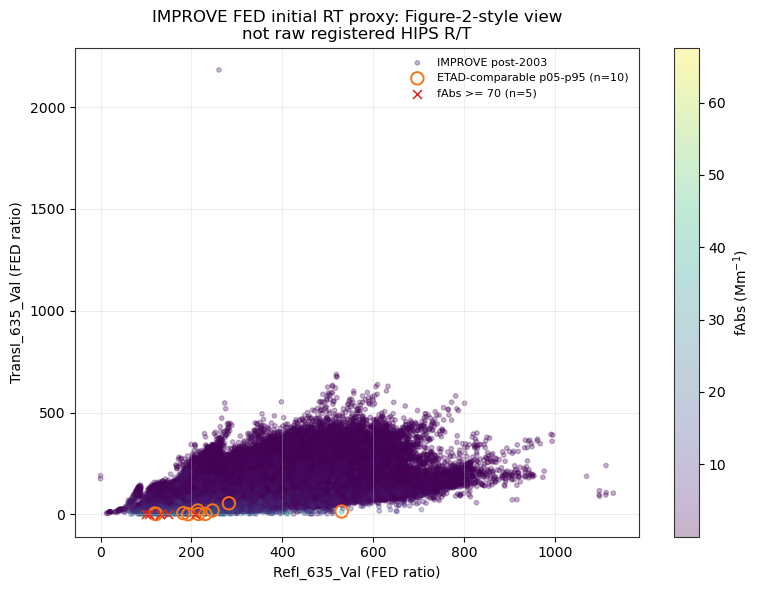

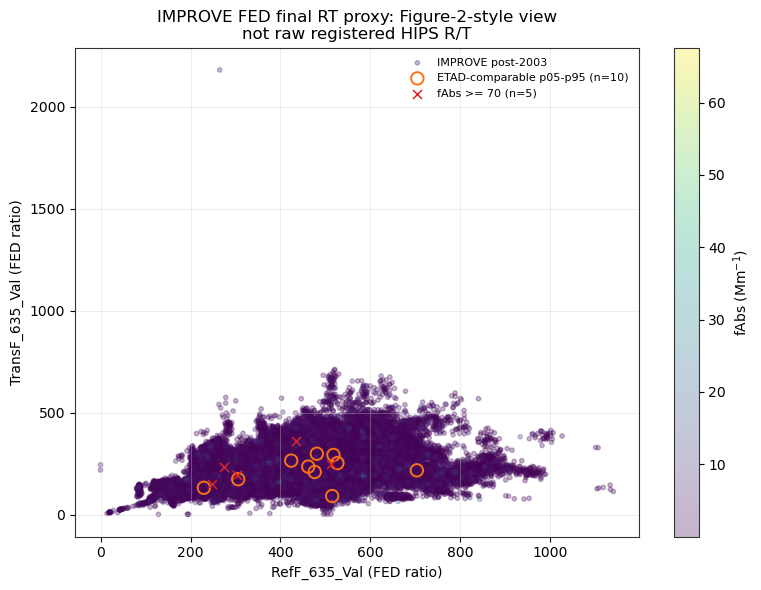

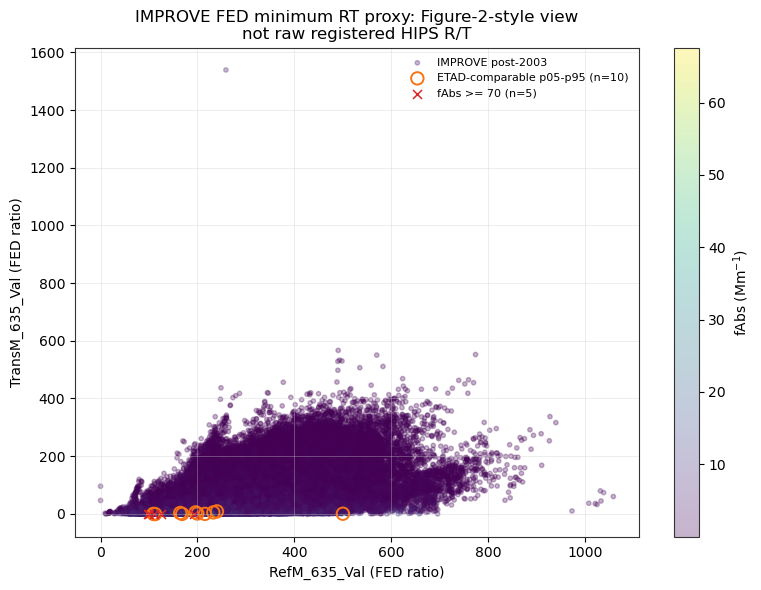

,pair,n,sites,year_min,year_max,etad_comparable_n,high_fabs_ge70_n,RefI_635_Val_median,TransI_635_Val_median,RefF_635_Val_median,TransF_635_Val_median,RefM_635_Val_median,TransM_635_Val_median
0,initial,147380,167,2016,2025,10,5,353.12,165.39,NaN,NaN,NaN,NaN
1,final,147380,167,2016,2025,10,5,NaN,NaN,397.4,216.86,NaN,NaN
2,minimum,147380,167,2016,2025,10,5,NaN,NaN,NaN,NaN,297.24,70.59


In [4]:
def plot_improve_proxy(pair_label, rcol, tcol, xlim=None, ylim=None):
    d = improve[improve['post_2003'] & improve[[rcol, tcol, 'fAbs_Val']].notna().all(axis=1)].copy()
    fig, ax = plt.subplots(figsize=(8, 6))
    if len(d) == 0:
        ax.text(0.5, 0.5, f'No {pair_label} RT proxy rows found', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return fig, ax, d

    draw = d.sample(min(80000, len(d)), random_state=42) if len(d) > 80000 else d
    sc = ax.scatter(draw[rcol], draw[tcol], c=draw['fAbs_Val'], s=10, alpha=0.30, cmap='viridis', rasterized=True, label='IMPROVE post-2003')

    comp = d[d['etad_comparable_p05p95']]
    high = d[d['high_fabs_ge70']]
    if len(comp):
        ax.scatter(comp[rcol], comp[tcol], s=80, facecolor='none', edgecolor='#F97316', linewidth=1.4, label=f'ETAD-comparable p05-p95 (n={len(comp)})')
    if len(high):
        ax.scatter(high[rcol], high[tcol], s=42, marker='x', color='#DC2626', linewidth=1.1, label=f'fAbs >= 70 (n={len(high)})')

    ax.set_xlabel(f'{rcol} (FED ratio)')
    ax.set_ylabel(f'{tcol} (FED ratio)')
    ax.set_title(f'IMPROVE FED {pair_label} RT proxy: Figure-2-style view\nnot raw registered HIPS R/T')
    ax.legend(frameon=False, fontsize=8)
    fig.colorbar(sc, ax=ax, label='fAbs (Mm$^{-1}$)')
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'improve_fed_{pair_label}_rt_proxy_figure2_style.png', dpi=230, bbox_inches='tight')
    return fig, ax, d

proxy_data = {}
for label, (rcol, tcol) in rt_pairs.items():
    fig, ax, d = plot_improve_proxy(label, rcol, tcol)
    proxy_data[label] = d
    plt.show()

summary = []
for label, d in proxy_data.items():
    rcol, tcol = rt_pairs[label]
    summary.append({
        'pair': label,
        'n': len(d),
        'sites': d['SiteCode'].nunique() if len(d) else 0,
        'year_min': d['year'].min() if len(d) else np.nan,
        'year_max': d['year'].max() if len(d) else np.nan,
        'etad_comparable_n': int(d['etad_comparable_p05p95'].sum()) if len(d) else 0,
        'high_fabs_ge70_n': int(d['high_fabs_ge70'].sum()) if len(d) else 0,
        f'{rcol}_median': d[rcol].median() if len(d) else np.nan,
        f'{tcol}_median': d[tcol].median() if len(d) else np.nan,
    })
summary = pd.DataFrame(summary)
summary.to_csv(OUT_DIR / 'improve_fed_rt_proxy_pair_summary.csv', index=False)
display(summary)

## Zoomed Views Around Highlighted Rows

If the ETAD-comparable/high-fAbs rows occupy a tiny part of the proxy space, these zooms make the points easier to inspect.

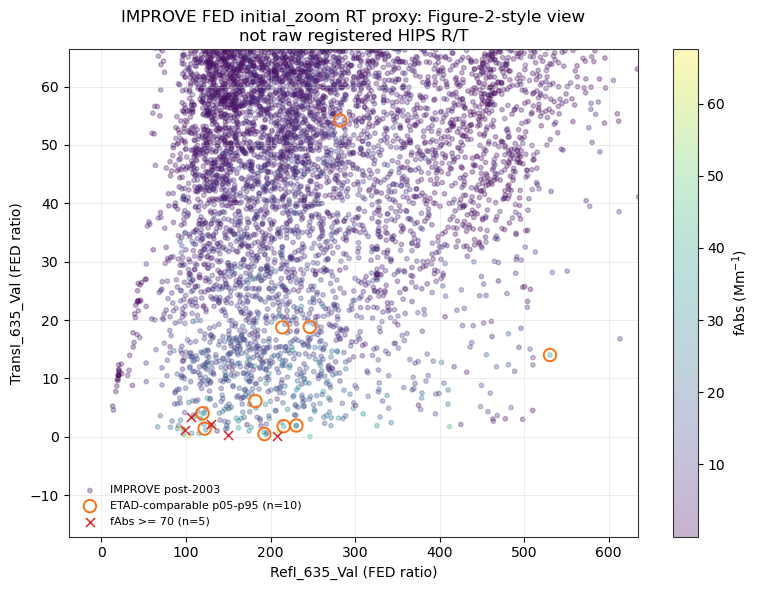

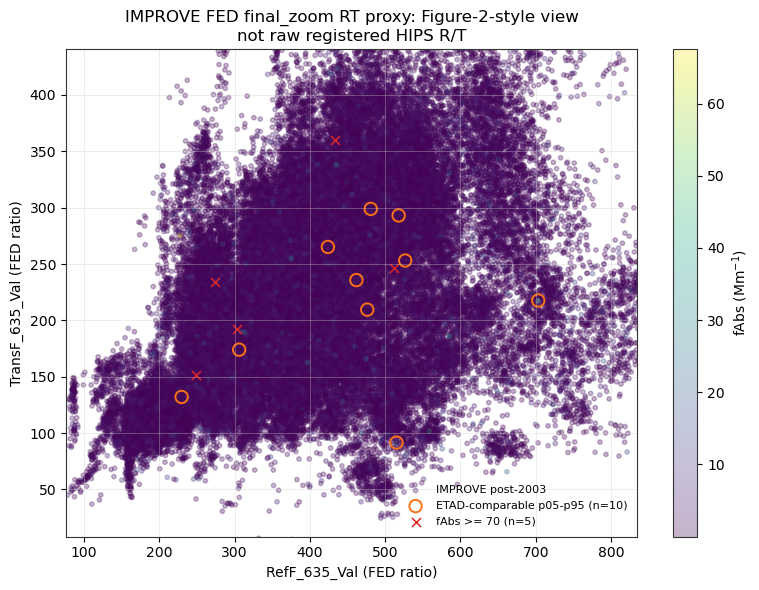

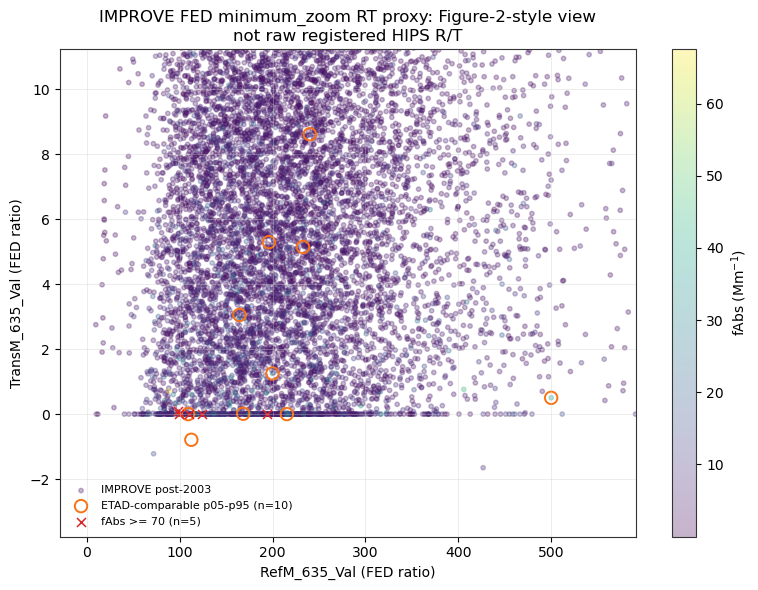

In [5]:
for label, d in proxy_data.items():
    rcol, tcol = rt_pairs[label]
    focus = d[d['etad_comparable_p05p95'] | d['high_fabs_ge70']].copy()
    if len(d) == 0 or len(focus) == 0:
        continue
    xr = focus[rcol].quantile([.01, .99]).to_numpy()
    yr = focus[tcol].quantile([.01, .99]).to_numpy()
    xpad = max((xr[1] - xr[0]) * .35, 1)
    ypad = max((yr[1] - yr[0]) * .35, 1)
    fig, ax, _ = plot_improve_proxy(label + '_zoom', rcol, tcol, xlim=(xr[0] - xpad, xr[1] + xpad), ylim=(yr[0] - ypad, yr[1] + ypad))
    plt.show()

## SPARTAN Raw R/T Analog

This is closer in spirit to Warren Figure 2 because the local SPARTAN table has raw-looking `HIPS_R1`, `HIPS_T1`, field blanks, samples, and lot IDs. It is still a SPARTAN analog, not the IMPROVE Figure 2 source record.

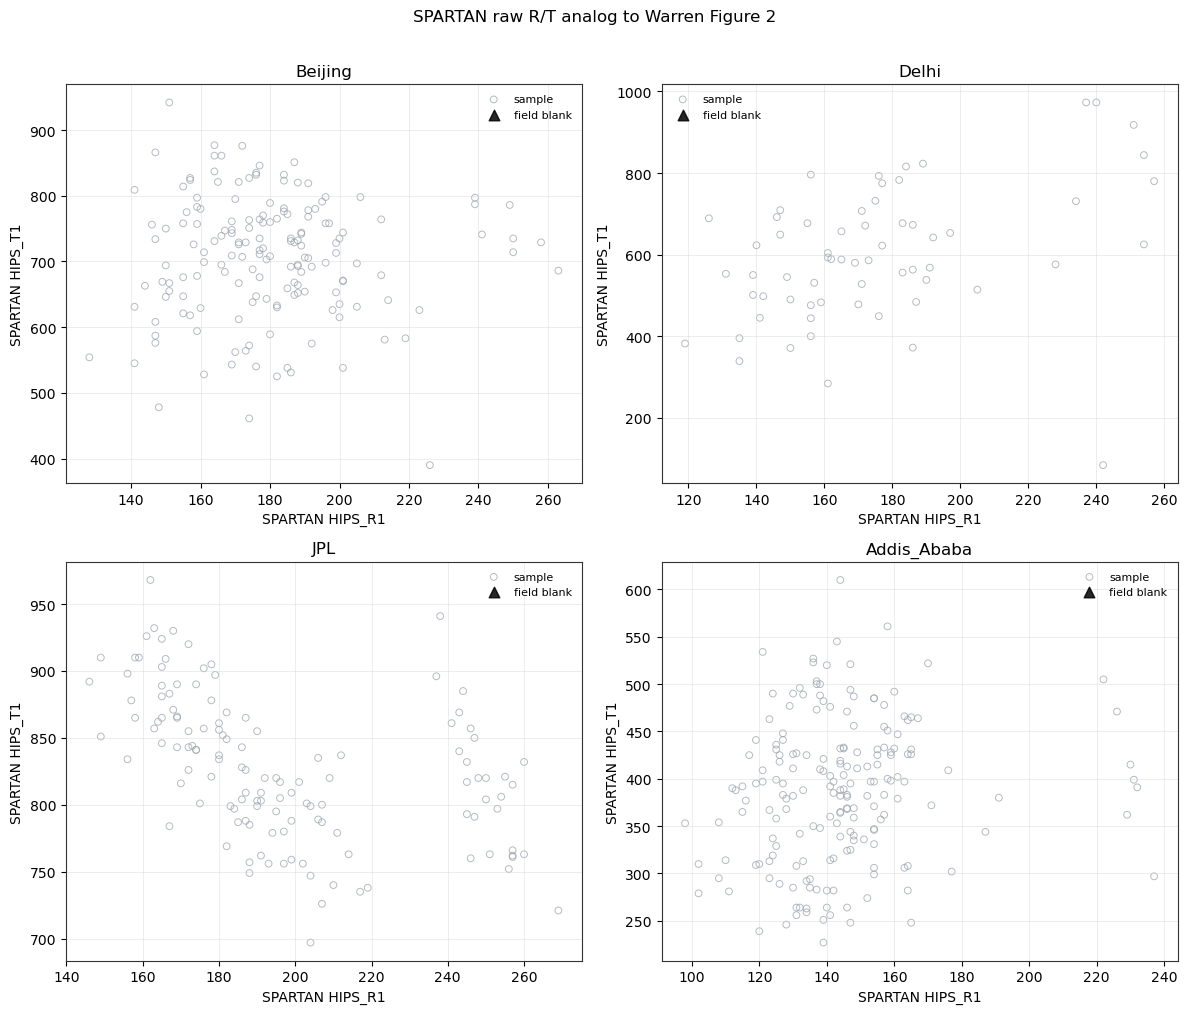

,SiteName,FilterType,LotId,n
0,Addis_Ababa,PM2.5,248.0,34
1,Addis_Ababa,PM2.5,251.0,156
2,Beijing,PM2.5,248.0,20
3,Beijing,PM2.5,251.0,143
4,Delhi,PM2.5,248.0,15
5,Delhi,PM2.5,251.0,48
6,JPL,PM2.5,248.0,14
7,JPL,PM2.5,251.0,116


In [6]:
rt = spartan_all[spartan_all['HIPS_R1'].notna() & spartan_all['HIPS_T1'].notna()].copy()
rt['status'] = np.where(rt['FilterType'].eq('FB'), 'field blank', 'sample')

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=False, sharey=False)
axes = axes.ravel()
for ax, site in zip(axes, SITE_ORDER):
    g = rt[rt['SiteName'].eq(site)].copy()
    samples = g[g['status'].eq('sample')]
    blanks = g[g['status'].eq('field blank')]
    ax.scatter(samples['HIPS_R1'], samples['HIPS_T1'], s=24, facecolor='none', edgecolor='#9CA3AF', linewidth=0.7, alpha=0.75, label='sample')
    ax.scatter(blanks['HIPS_R1'], blanks['HIPS_T1'], s=58, marker='^', color='black', alpha=0.85, label='field blank')
    # Fit blank line only when there are enough blanks, matching the Figure 2 visual idea.
    if len(blanks.dropna(subset=['HIPS_R1', 'HIPS_T1'])) >= 3:
        x = blanks['HIPS_R1'].to_numpy(float)
        y = blanks['HIPS_T1'].to_numpy(float)
        m, b0 = np.polyfit(x, y, 1)
        xline = np.linspace(g['HIPS_R1'].min(), g['HIPS_R1'].max(), 100)
        ax.plot(xline, m * xline + b0, color='#238B45', ls='--', lw=2, label=f'blank OLS: y={m:.2f}x+{b0:.0f}')
    ax.set_title(site)
    ax.set_xlabel('SPARTAN HIPS_R1')
    ax.set_ylabel('SPARTAN HIPS_T1')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('SPARTAN raw R/T analog to Warren Figure 2', y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / 'spartan_raw_rt_figure2_analog_all_sites.png', dpi=230, bbox_inches='tight')
plt.show()

rt_counts = rt.groupby(['SiteName', 'FilterType', 'LotId'], dropna=False).size().rename('n').reset_index()
rt_counts.to_csv(OUT_DIR / 'spartan_raw_rt_counts_by_site_filtertype_lot.csv', index=False)
display(rt_counts.sort_values(['SiteName', 'FilterType', 'LotId']))

## Takeaway

Use the generated IMPROVE proxy figures to decide whether the FED RT export is visually informative. If we need a true Warren Figure 2 reproduction, the request to Warren/Alex should ask for raw registered HIPS `R,T` records with field blank/sample status, filter lot, analysis batch/date, and the blank OLS coefficients used for the relevant IMPROVE and SPARTAN filters.

In [7]:
print('Generated files:')
for path in sorted(OUT_DIR.glob('*')):
    print(path)

Generated files:
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_fed_rt_proxy_figure2/etad_bounds_for_rt_proxy.csv
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_fed_rt_proxy_figure2/improve_fed_final_rt_proxy_figure2_style.png
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_fed_rt_proxy_figure2/improve_fed_final_zoom_rt_proxy_figure2_style.png
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_fed_rt_proxy_figure2/improve_fed_initial_rt_proxy_figure2_style.png
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_fed_rt_proxy_figure2/improve_fed_initial_zoom_rt_proxy_figure2_style.png
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_fed_rt_proxy_figure2/improve_fed_minimum_rt_proxy_figure2_style.png
/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_fed_rt_proxy_figure2